In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("featureReduction.ipynb")

## Lecture Section

In this lecture, we will cover aspects of feature/dimensionality reduction.
We will cover:
* Principal Component Analysis (PCA)
* Nonlinear Dimensionality Reduction
    * Multidimension Scaling
    * t-SNE

Some of this lecture is borrowed from:
https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html


These helper functions will be useful later, so I am placing them up here.

In [6]:
import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401
from matplotlib import ticker

from sklearn import datasets, manifold

n_samples = 1500
S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)

def plot_3d(points, points_color, title):
    x, y, z = points.T

    fig, ax = plt.subplots(
        figsize=(6, 6),
        facecolor="white",
        tight_layout=True,
        subplot_kw={"projection": "3d"},
    )
    fig.suptitle(title, size=16)
    col = ax.scatter(x, y, z, c=points_color, s=50, alpha=0.8)
    ax.view_init(azim=-60, elev=9)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.zaxis.set_major_locator(ticker.MultipleLocator(1))

    fig.colorbar(col, ax=ax, orientation="horizontal", shrink=0.6, aspect=60, pad=0.01)
    plt.show()


def plot_2d(points, points_color, title):
    fig, ax = plt.subplots(figsize=(3, 3), facecolor="white", constrained_layout=True)
    fig.suptitle(title, size=16)
    add_2d_scatter(ax, points, points_color)
    plt.show()


def add_2d_scatter(ax, points, points_color, title=None):
    x, y = points.T
    ax.scatter(x, y, c=points_color, s=50, alpha=0.8)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())


### Principal Component Analysis

Principal Component Analysis (PCA) is one of the most common dimensionality reduction techniques. Unlike MDS and t-SNE, PCA is a linear method — it finds new axes (principal components) that capture the most variance in your data. The first component captures the most variance, the second captures the next most, and so on.

PCA works best on linear data. However, we are going to use a classic s-curve dataset to view our dimensionality reduction on nonlinear data and PCA works surprisingly well for that, too!


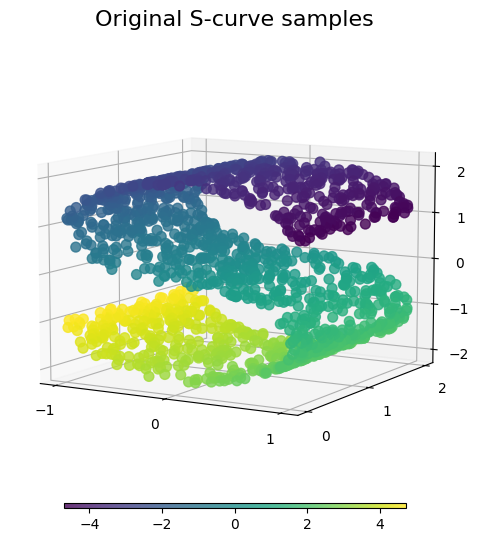

In [7]:
plot_3d(S_points, S_color, "Original S-curve samples")

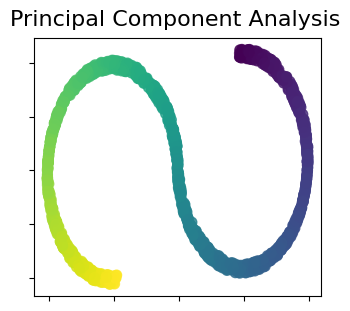

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
S_pca = pca.fit_transform(S_points)

plot_2d(S_pca, S_color, "Principal Component Analysis")

PCA gives us two new coordinates. We can check how much of the original variance each component explains — this tells us how much information we retained after reducing from 3D to 2D.

In [9]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Explained variance ratio: [0.69133634 0.18724734]
Total variance explained: 87.86 %


The explained variance ratio tells us what proportion of the total variance in the data each principal component captures. A higher total means less information was lost in the reduction. Because the S-curve is nonlinear, PCA will retain less structure than t-SNE — you can compare the two plots to see this clearly.

Mathematically, the PCAs are computed by eigendecomposition:
1. **Center the data** — subtract the mean of each feature so the data is centered at the origin
2. **Compute the covariance matrix** — this captures how features vary together
3. **Eigendecompose the covariance matrix** — eigenvectors give the directions of maximum variance (the principal components), and eigenvalues tell us how much variance each direction captures
4. **Project the data** onto the top `k` eigenvectors to get the reduced representation

In [10]:
import numpy as np
# Step 1: center the data
X = S_points
X_centered = X - X.mean(axis=0)

# Step 2: compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)
print(cov_matrix)

# Step 3: eigendecompose the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh returns in ascending order — we want descending
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Eigenvalues:", eigenvalues)
print("Explained variance ratio (manual):", eigenvalues / eigenvalues.sum())

Covariance matrix shape: (3, 3)
[[ 0.52193881 -0.00762459 -0.07524663]
 [-0.00762459  0.33654402 -0.01366077]
 [-0.07524663 -0.01366077  1.90926277]]
Eigenvalues: [1.9134431  0.51825301 0.33604949]
Explained variance ratio (manual): [0.69133634 0.18724734 0.12141632]


In [11]:
# Step 4: project onto top 2 eigenvectors
S_pca_manual = X_centered @ eigenvectors[:, :2]

print("manual explained variance ratio:   ", (eigenvalues / eigenvalues.sum())[:2])

manual explained variance ratio:    [0.69133634 0.18724734]


The two plots should look identical (or mirrored — flipping an axis doesn't change the meaning of a principal component). The explained variance ratios match exactly. sklearn is just doing this eigendecomposition for you under the hood, with some additional numerical stability tricks.

### Multidimensional Scaling (MDS)

PCA is quick and easy, but it struggles with high-dimension, non-linear data. There are other options for non-linear data.

Multidimensional scaling tries to map pairwise distances into a geometric representation in a lower-dimensional space. For us, this means that our 3D `S` should become a 2D `S`. We can adjust the 'smoothness' of our `S` with a few different options, too.

You can read more about MDS here:
https://www.geeksforgeeks.org/data-analysis/what-is-multidimensional-scaling/

In [12]:
n_neighbors = 12
n_components = 2  # number of new coordinates

md_scaling = manifold.MDS(
    n_components=n_components,
    max_iter=50,
    n_init=1,
    random_state=0,
    init="classical_mds",
    normalized_stress=False,
)
S_scaling_metric = md_scaling.fit_transform(S_points)

md_scaling_nonmetric = manifold.MDS(
    n_components=n_components,
    max_iter=50,
    n_init=1,
    random_state=0,
    normalized_stress=False,
    metric_mds=False,
    init="classical_mds",
)
S_scaling_nonmetric = md_scaling_nonmetric.fit_transform(S_points)

md_scaling_classical = manifold.ClassicalMDS(n_components=n_components)
S_scaling_classical = md_scaling_classical.fit_transform(S_points)

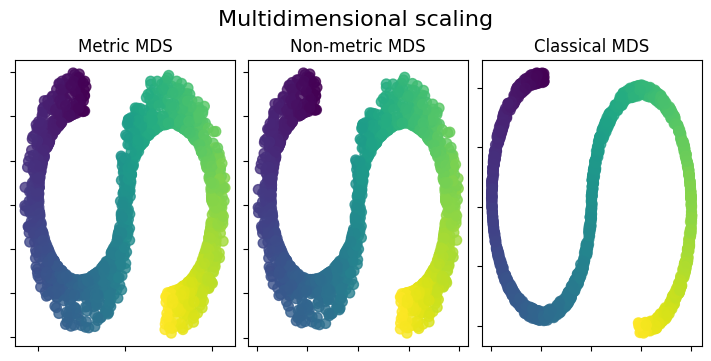

In [13]:
fig, axs = plt.subplots(
    nrows=1, ncols=3, figsize=(7, 3.5), facecolor="white", constrained_layout=True
)
fig.suptitle("Multidimensional scaling", size=16)

mds_methods = [
    ("Metric MDS", S_scaling_metric),
    ("Non-metric MDS", S_scaling_nonmetric),
    ("Classical MDS", S_scaling_classical),
]
for ax, method in zip(axs.flat, mds_methods):
    name, points = method
    add_2d_scatter(ax, points, S_color, name)

plt.show()

### t-SNE

T-distributed Stochastic Neighbor Embedding (t-SNE) converts similarities between points into joint probabilities. It tries to minimize the divergence between the joint probabilities between the low and high dimensional data. It's cost function can significantly change your results.

t-SNE is unique because it is based on probability, and it works well with text and clustered data. However, it is very computationally expensive and global structure is not retained. However, you can somewhat retain the global structure by setting `init = 'pca'`.

You can read more about t-SNE parameters here:
https://distill.pub/2016/misread-tsne/

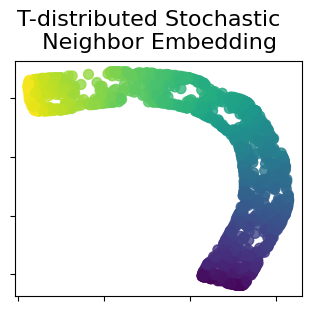

In [14]:
t_sne = manifold.TSNE(
    n_components=n_components,
    perplexity=30,
    init="random",
    max_iter=250,
    random_state=0,
)
S_t_sne = t_sne.fit_transform(S_points)

plot_2d(S_t_sne, S_color, "T-distributed Stochastic  \n Neighbor Embedding")

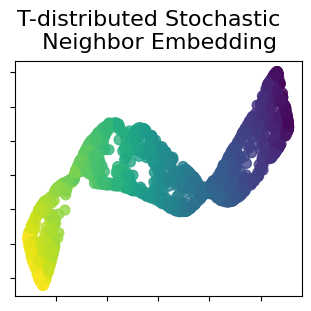

In [15]:
t_sne = manifold.TSNE(
    n_components=n_components,
    perplexity=30,
    init="pca",
    max_iter=250,
    random_state=0,
)
S_t_sne = t_sne.fit_transform(S_points)

plot_2d(S_t_sne, S_color, "T-distributed Stochastic  \n Neighbor Embedding")

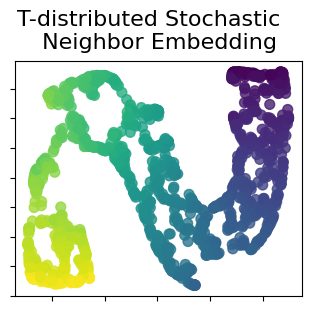

In [16]:
t_sne = manifold.TSNE(
    n_components=n_components,
    perplexity=10,
    init="pca",
    max_iter=250,
    random_state=0,
)
S_t_sne = t_sne.fit_transform(S_points)

plot_2d(S_t_sne, S_color, "T-distributed Stochastic  \n Neighbor Embedding")

## Assignment Section

**Question 1.**

Apply PCA to `S_points` with `n_components=3` and `random_state=0`. Store the result in `S_pca_3d` and the fitted PCA object in `pca_3d`.

In [30]:
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3, random_state=0)
S_pca_3d = pca_3d.fit_transform(S_points)

#plot_3d(S_pca_3d, S_color, "Principal Component Analysis")

In [28]:
grader.check("q1")

q1 results: All test cases passed!

**Question 2.**
Using `pca_3d` from Q1, how many components would you need to retain at least 80% of the variance? Assign your answer as an integer to `n_components_80`.

In [31]:
print(pca_3d.explained_variance_ratio_)

[0.69133634 0.18724734 0.12141632]


In [32]:
n_components_80 = 2

In [33]:
grader.check("q2")

q2 results: All test cases passed!

**Question 3.**

Assign 'PCA', 'MDS', and 'TSNE' to the variable that best matches it.

In [34]:
distance = "MDS"
linear = "PCA"
probability = "TSNE"

In [35]:
grader.check("q3")

q3 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()